In [1]:
import seaborn as sns

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np 

import h5py
from scipy.integrate import simpson
from scipy.optimize import curve_fit
from matplotlib.ticker import AutoMinorLocator

plt.rc('axes', linewidth=3, labelsize=22)
plt.rc('xtick', labelsize=22)  # fontsize of the x tick labels
plt.rc('ytick', labelsize=22)  # fontsize of the y tick labels
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'  # Axis labels
plt.rcParams['axes.titleweight'] = 'bold' 

sns.set_theme(font_scale=2.25)
sns.set_style("white")


In [2]:


def apply_ax_format(ax,xlabel="",ylabel="",title="",legend=False,inset=False):
    if not inset:
        ax.spines['bottom'].set_color('0')
        ax.spines['top'].set_color('1')
        ax.spines['right'].set_color('1')
        ax.spines['left'].set_color('0')
    ax.tick_params(which="both",direction='out', width=3, bottom=True, left=True)
    ax.grid(False)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.xaxis.set_minor_locator(AutoMinorLocator(4))
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))
    if legend:
        plt.setp(ax.get_legend().get_texts(), fontsize='22') # for legend text
        plt.setp(ax.get_legend().get_title(), fontsize='22') # for legend title



In [3]:


# Fit the resolution data to a polynomial for extrapolation
def poly_func(x, a, b, c):
    return a * x**2 + b * x + c

# Create a function to get resolution for any energy
def get_resolution(e,popt):
    return np.maximum(poly_func(e, *popt), 1e-10)  # Ensure non-zero resolution


# Perform Gaussian broadening using convolution with energy-dependent widths
def gaussian_broadening(dos, energy, sigmas):
    broadened_dos = np.zeros_like(dos)
    for i in range(len(energy)):
        # Create a Gaussian kernel centered at each energy point with width sigmas[i]
        kernel = np.exp(-0.5 * ((energy - energy[i]) / sigmas[i])**2)
        kernel /= simpson(kernel, energy)  # Normalize the kernel to preserve area
        broadened_dos += dos[i] * kernel  # Convolve DOS with Gaussian kernel
    return broadened_dos

def apply_gaussian_broadening(dos_data,metric='dos total (nm2/ps)',unit_cell_atoms=1):
    energy = dos_data['Energy Transfer (meV)'].values
    dos = dos_data[metric].values

    resolution_data = pd.read_csv('../data/hresolution.csv')
    res_energy = resolution_data['Energy (meV)'].values
    resolution = resolution_data['Resolution'].values
    popt, _ = curve_fit(poly_func, res_energy, resolution)
    
    # Create an array of sigmas for Gaussian broadening based on the resolution function
    sigmas = get_resolution(energy,popt) / np.sqrt(8 * np.log(2))  # Convert FWHM to sigma


    broadened_dos = gaussian_broadening(dos, energy, sigmas)

    # Area normalize both original and broadened DOS
    original_area = simpson(dos, energy)
    broadened_area = simpson(broadened_dos, energy)

    dos_normalized = dos / original_area
    #dos_normalized-=dos_normalized[0]
    broadened_dos_normalized = broadened_dos / broadened_area
    return dos_normalized #3*unit_cell_atoms*broadened_dos_normalized

In [4]:
results_directory=dict()
for temperature in np.arange(100,450,50):
    for subset in ["H2O","SiO2","Total"]:
        results_directory["../results/gromacs/pore/4nm/H2O/results_720/%d/%s/out_dos.h5" % (temperature,subset)]=(temperature,subset)

df_list=list()

min_energy=0
max_energy=1500
subset_map={"H2O":"$H_2O$","SiO2":"$SiO_2$","Total":"Total"}
for pdos_file,(temperature,subset) in results_directory.items():
    print(pdos_file)
    h5file=h5py.File(pdos_file)
    data_dict=dict()
    omega_shape=h5file["omega"][:].shape
    for k in h5file.keys():
        data_array=h5file[k][:]
        if data_array.shape != omega_shape or "_0" in k:
            continue
        units=h5file[k].attrs['units']
        data_dict["%s (%s)"%(k.replace("_"," "),units)]=data_array
    h5file.close()
    df_tmp=pd.DataFrame(data_dict).query("%f < `omega (rad/ps)` and `omega (rad/ps)` < %f"%(min_energy/0.6582,max_energy/0.6582))
    df_tmp["Energy Transfer (meV)"]=df_tmp["omega (rad/ps)"]*0.6582
    df_tmp["Normalized Count"]=apply_gaussian_broadening(df_tmp)
    df_tmp["Max Normalized Count"]=df_tmp["Normalized Count"]/df_tmp["Normalized Count"].max()
    df_tmp["Temperature (K)"]=temperature
    df_tmp["Subset"]=subset_map[subset]
    df_list.append(df_tmp)
        
df_dos_mdanse=pd.concat(df_list,ignore_index=True)
df_dos_mdanse

../results/gromacs/pore/4nm/H2O/results_720/100/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/100/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/100/Total/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/150/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/150/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/150/Total/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/200/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/200/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/200/Total/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/250/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/250/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/250/Total/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/300/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/300/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/300/Total/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_

,dos H (nm2/ps),dos M (nm2/ps),dos O (nm2/ps),dos total (nm2/ps),omega (rad/ps),omega window (au),time window (au),Energy Transfer (meV),Normalized Count,Max Normalized Count,Temperature (K),Subset,dos Si (nm2/ps)
0,0.000014,0.000010,1.033359e-05,0.000014,0.062835,2.501685,9.999875e-01,0.041358,0.000074,0.003310,100,$H_2O$,NaN
1,0.000014,0.000011,1.044359e-05,0.000014,0.125670,2.486913,9.999500e-01,0.082716,0.000074,0.003343,100,$H_2O$,NaN
2,0.000014,0.000011,1.062712e-05,0.000014,0.188505,2.462486,9.998875e-01,0.124074,0.000076,0.003397,100,$H_2O$,NaN
3,0.000014,0.000011,1.088446e-05,0.000014,0.251340,2.428692,9.998000e-01,0.165432,0.000077,0.003474,100,$H_2O$,NaN
4,0.000015,0.000011,1.121602e-05,0.000015,0.314175,2.385922,9.996875e-01,0.206790,0.000080,0.003572,100,$H_2O$,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
209974,0.000022,NaN,2.523867e-08,0.000021,628.035787,0.000000,3.716009e-17,413.373155,0.000033,0.001578,400,Total,6.103163e-08
209975,0.000022,NaN,2.524778e-08,0.000021,628.098622,0.000000,2.741944e-18,413.414513,0.000033,0.001578,400,Total,6.105807e-08
209976,0.000022,NaN,2.525467e-08,0.000021,628.161457,0.000000,4.071618e-17,413.455871,0.000033,0.001579,400,Total,6.107806e-08
209977,0.000022,NaN,2.525930e-08,0.000021,628.224292,0.000000,8.530829e-18,413.497229,0.000033,0.001579,400,Total,6.109147e-08


In [5]:
results_directory=dict()
for temperature in np.arange(100,450,50):
    for subset in ["H2O","SiO2","Total"]:
        results_directory["../results/gromacs/pore/4nm/H2O/results_720_le/%d/%s/dos.csv" % (temperature,subset)]=(temperature,subset)

df_list=list()
for pdos_file,(temperature,subset) in results_directory.items():
    df_tmp=pd.read_csv(pdos_file,names=['Wave number $(cm^{-1})',"dos","dos(solid)","dos(diff)"],skiprows=1)
    df_tmp["Temperature (K)"]=temperature
    df_tmp["Subset"]=subset_map[subset]
    df_tmp['Energy Transfer (meV)']=df_tmp['Wave number $(cm^{-1})']*0.124
    dos=df_tmp["dos(solid)"].values
    energy=df_tmp["Energy Transfer (meV)"].values
    original_area = simpson(dos, energy)
    df_tmp["Normalized Count"] = apply_gaussian_broadening(df_tmp,metric="dos(solid)")
    df_tmp["Max Normalized Count"] = df_tmp["Normalized Count"]/df_tmp["Normalized Count"].max()
    df_list.append(df_tmp)

df_dos_gmx=pd.concat(df_list,ignore_index=True)
df_dos_gmx

,Wave number $(cm^{-1}),dos,dos(solid),dos(diff),Temperature (K),Subset,Energy Transfer (meV),Normalized Count,Max Normalized Count
0,0.000000,37.2917,0.000000,37.2917,100,$H_2O$,0.000000,0.000000,0.000000
1,0.162714,36.6465,-0.644711,37.2912,100,$H_2O$,0.020177,-0.000663,-0.012408
2,0.325428,37.9832,0.693614,37.2896,100,$H_2O$,0.040353,0.000713,0.013349
3,0.488143,36.4880,-0.798955,37.2870,100,$H_2O$,0.060530,-0.000822,-0.015376
4,0.650857,37.0367,-0.246547,37.2833,100,$H_2O$,0.080706,-0.000254,-0.004745
...,...,...,...,...,...,...,...,...,...
26245,202.579000,347.1860,334.563000,12.6234,400,Total,25.119796,0.046619,0.877805
26246,202.742000,346.5560,333.952000,12.6039,400,Total,25.140008,0.046533,0.876202
26247,202.905000,350.1740,337.590000,12.5845,400,Total,25.160220,0.047040,0.885747
26248,203.067000,345.9590,333.394000,12.5651,400,Total,25.180308,0.046456,0.874738


,Temperature (K),a(T),b(T),c(T),emax,$a_0$,$a_1$,$a_2$,$a_4$,$n_1$,$n_2$,$n_4$,$\Delta a_0$,$\Delta a_1$,$\Delta a_2$,$\Delta a_4$,Subset
0,100,0.000147,2.054655,0.000074,1.0,0.000059,0.000063,0.000059,0.000055,0.356514,0.334530,0.308956,3.473644e-11,1.722343e-09,4.565176e-09,1.283153e-09,$H_2O$
1,100,0.000147,2.067153,0.000074,1.1,0.000058,0.000065,0.000058,0.000053,0.367611,0.332574,0.299814,4.643199e-11,1.978135e-09,4.499086e-09,9.274407e-10,$H_2O$
2,100,0.000147,2.089535,0.000074,1.2,0.000054,0.000068,0.000058,0.000050,0.387620,0.328992,0.283388,8.338464e-11,2.885365e-09,5.321528e-09,7.177624e-10,$H_2O$
3,100,0.000147,2.106999,0.000074,1.3,0.000065,0.000062,0.000051,0.000041,0.403266,0.331112,0.265623,9.158354e-12,2.789620e-10,4.524801e-10,4.707275e-11,$H_2O$
4,100,0.000147,2.126510,0.000075,1.4,0.000065,0.000062,0.000050,0.000039,0.411680,0.330302,0.258018,1.321895e-11,3.571564e-10,5.134542e-10,4.185809e-11,$H_2O$
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,400,0.000322,1.709823,0.005697,1.2,0.005692,0.000142,0.000105,0.000074,0.441986,0.327146,0.230867,1.048462e-10,3.628002e-09,6.691186e-09,9.025006e-10,Total
143,400,0.000322,1.675525,0.005696,1.3,0.005687,0.000117,0.000207,0.000004,0.356508,0.632193,0.011300,1.750425e-11,5.331767e-10,8.648197e-10,8.996959e-11,Total
144,400,0.000322,1.640199,0.005694,1.4,0.005684,0.000136,0.000190,0.000004,0.411200,0.577716,0.011084,2.416650e-11,6.529433e-10,9.386825e-10,7.652379e-11,Total
145,400,0.000325,1.585485,0.005691,1.5,0.005677,0.000171,0.000158,0.000005,0.511971,0.472182,0.015847,4.043527e-11,9.241553e-10,1.122708e-09,6.514969e-11,Total


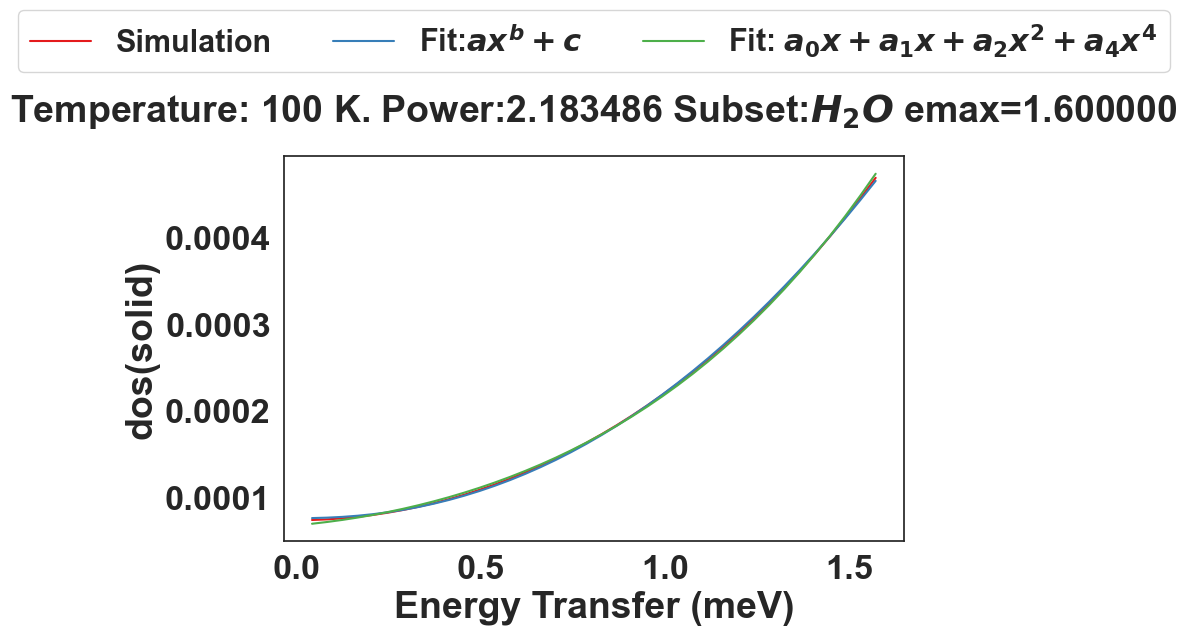

In [6]:
def power(x,a,b,c):
    return a*x**b+c

def taylor_series(x,a0,a1,a2,a4):
    return a0+a1*x+a2*x**2+a4*x**4

emax_l=1.0
emax_r=1.6
d_emax=0.1
df_data=df_dos_mdanse.copy()
df_list=list()
for i,subset in enumerate(df_data["Subset"].unique()):
    data_list=list()
    for j,temperature in enumerate(df_data["Temperature (K)"].unique()):
        for emax in np.arange(emax_l,emax_r,d_emax):        
            df_tmp=df_data.query("0 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(emax,temperature,subset))
            xdata=df_tmp["Energy Transfer (meV)"].values
            ydata=df_tmp["Normalized Count"].values
            popt, pcov = curve_fit(power, xdata, ydata,p0=[1,3,0],method='lm')
            popt_14, pcov_14 = curve_fit(taylor_series, xdata, ydata,p0=[1,1,1,1],bounds=([-np.inf,0,0,0],[np.inf,np.inf,np.inf,np.inf]),method='trf')
            
            norm=np.sum(np.abs(popt_14[1:]))
            cv_14=np.diag(pcov_14)
            data_list.append({
                "Temperature (K)":temperature
                , "a(T)":popt[0]
                , "b(T)":popt[1]
                , "c(T)":popt[2] 
                ,"emax":emax
                ,"$a_0$":popt_14[0]
                ,"$a_1$":popt_14[1]
                ,"$a_2$":popt_14[2]
                #,"$a_3$":popt_14[3]
                ,"$a_4$":popt_14[3]
                ,"$n_1$":popt_14[1]/norm
                ,"$n_2$":popt_14[2]/norm
                #,"$n_3$":popt_14[3]/norm
                ,"$n_4$":popt_14[3]/norm
                ,"$\\Delta a_0$":cv_14[0]
                ,"$\\Delta a_1$":cv_14[1]
                ,"$\\Delta a_2$":cv_14[2]
                #,"$\\Delta a_3$":cv_14[3]
                ,"$\\Delta a_4$":cv_14[3]
                             })
        if i>0 or j>0:
            continue

        fig, ax = plt.subplots(figsize=(8,5))
        df_fit=pd.concat([
            pd.DataFrame({"Energy Transfer (meV)":xdata,"dos(solid)":ydata,"data":"Simulation"})
            ,pd.DataFrame({"Energy Transfer (meV)":xdata,"dos(solid)": power(xdata, *popt),"data":"Fit:$ax^b+c$"})
            ,pd.DataFrame({"Energy Transfer (meV)":xdata,"dos(solid)": taylor_series(xdata, *popt_14),"data":"Fit: $a_0x+a_1x+a_2x^2+a_4x^4$"})
        ],ignore_index=True)
        sns.lineplot(data=df_fit
            , y='dos(solid)'
                 , x='Energy Transfer (meV)'
                 ,ax=ax
                ,hue='data'
                 ,palette='Set1'
                )
        ax.set_title("Temperature: %d K. Power:%f Subset:%s emax=%f"%(temperature,popt[1],subset,emax),pad=25)
        sns.move_legend(ax,'center',bbox_to_anchor=(0.5,1.3),ncol=4,fontsize=22,title_fontsize=22,title="")


    df_tmp=pd.DataFrame(data_list)
    df_tmp["Subset"]=subset
    df_list.append(df_tmp)
    
df_power=pd.concat(df_list,ignore_index=True)
    
df_power

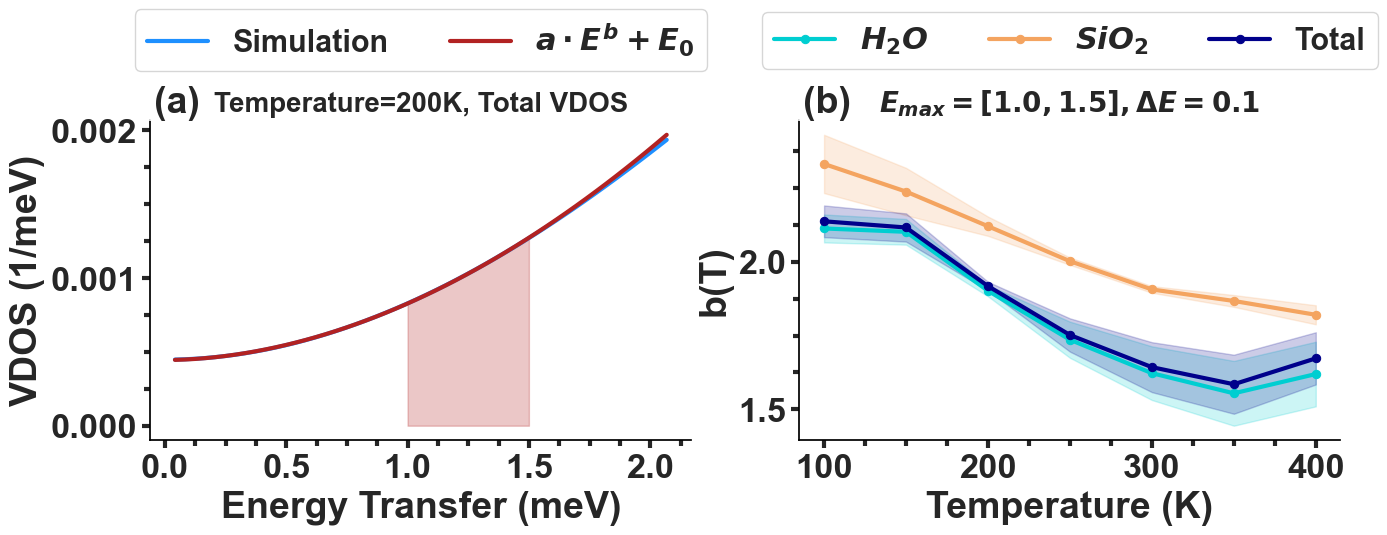

In [15]:
fig, axs = plt.subplots(ncols=2,figsize=(7*2,4))
labx=0.00625
laby=1.025
index=["(%s)"%x for x in list("abcdefghijkl")]

temperature=200
ax=axs[0]
ax.text(labx, laby, index[0],weight='bold' ,transform=ax.transAxes)
df_tmp=df_data.query("`Temperature (K)`==%d and Subset == 'Total' and `Energy Transfer (meV)` < %f"%(temperature,emax_r+5*d_emax))
sns.lineplot(data=df_tmp
            ,y="Normalized Count"
            ,x="Energy Transfer (meV)"
            ,ax=ax
            ,lw=3
            ,label="Simulation" 
             ,color='dodgerblue'
       )
xdata=df_tmp["Energy Transfer (meV)"].values
ds=df_power.query("`Temperature (K)`==%d and Subset == 'Total' and emax >= %f"%(temperature,emax-d_emax))
a,b,c=ds[["a(T)","b(T)","c(T)"]].values[0]
df_fit=pd.DataFrame({"Energy Transfer (meV)":xdata,"Fitted VDOS (1/meV)": power(xdata,a,b,c),"data":"Fit:$ax^b+c$"})
sns.lineplot(data=df_fit
            ,y="Fitted VDOS (1/meV)"
            ,x="Energy Transfer (meV)"
            ,ax=ax
             ,lw=3
            ,label="$a\cdot E^b+E_0$" 
             ,color='firebrick'
       )


apply_ax_format(ax,xlabel="Energy Transfer (meV)",ylabel="VDOS (1/meV)")

legend_y=1.25
sns.move_legend(ax,'center',bbox_to_anchor=(0.5,legend_y),ncol=3,fontsize=22,title_fontsize=22,title="")
ax.set_title("Temperature=%dK, Total VDOS"%temperature,fontsize=20)
ymax=df_fit["Fitted VDOS (1/meV)"].max()
#ax.vlines(x=emax_l,ymin=0,ymax=ymax,colors='firebrick',linestyles='--')
#ax.vlines(x=3.5,ymin=0,ymax=ymax,colors='firebrick',linestyles='--')

xdata=np.linspace(emax_l,emax_r-d_emax)
ax.fill_between(xdata, 0, power(xdata,a,b,c),color='firebrick', alpha=0.25)

ax=axs[1]
ax.text(labx, laby, index[1],weight='bold' ,transform=ax.transAxes)

sns.lineplot(data=df_power
            , y='b(T)'
                 , x='Temperature (K)'
                 ,ax=ax
                 ,marker='o'
#                 ,markerfacecolor="grey"
                 ,markeredgecolor=None
                ,hue='Subset'
             ,lw=3
             ,errorbar="sd"
                 ,palette=["darkturquoise","sandybrown","darkblue"]
                )


apply_ax_format(ax,legend=True,xlabel="Temperature (K)",ylabel="b(T)")
ax.set_title("$E_{max}=[%.1f,%.1f],\\Delta E=%.1f$"%(df_power["emax"].min(),df_power["emax"].max()-df_power["emax"].diff().max(),df_power["emax"].diff().max()),fontsize=20)
sns.move_legend(ax,'center',bbox_to_anchor=(0.5,legend_y),ncol=3,fontsize=22,title_fontsize=22,title="")

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.95, 
                    top=0.9, 
                    wspace=0.2, 
                    hspace=0.
                   )

plt.savefig("../figures/fig11.pdf", pad_inches=0.2,bbox_inches="tight")

In [8]:
df_taylor_fit=pd.melt(df_power[["Temperature (K)","Subset","$n_1$","$n_2$","$n_4$"]],id_vars=["Temperature (K)","Subset"],value_vars=["$n_1$","$n_2$","$n_4$"])
df_taylor_fit

,Temperature (K),Subset,variable,value
0,100,$H_2O$,$n_1$,0.356514
1,100,$H_2O$,$n_1$,0.367611
2,100,$H_2O$,$n_1$,0.387620
3,100,$H_2O$,$n_1$,0.403266
4,100,$H_2O$,$n_1$,0.411680
...,...,...,...,...
436,400,Total,$n_4$,0.230867
437,400,Total,$n_4$,0.011300
438,400,Total,$n_4$,0.011084
439,400,Total,$n_4$,0.015847


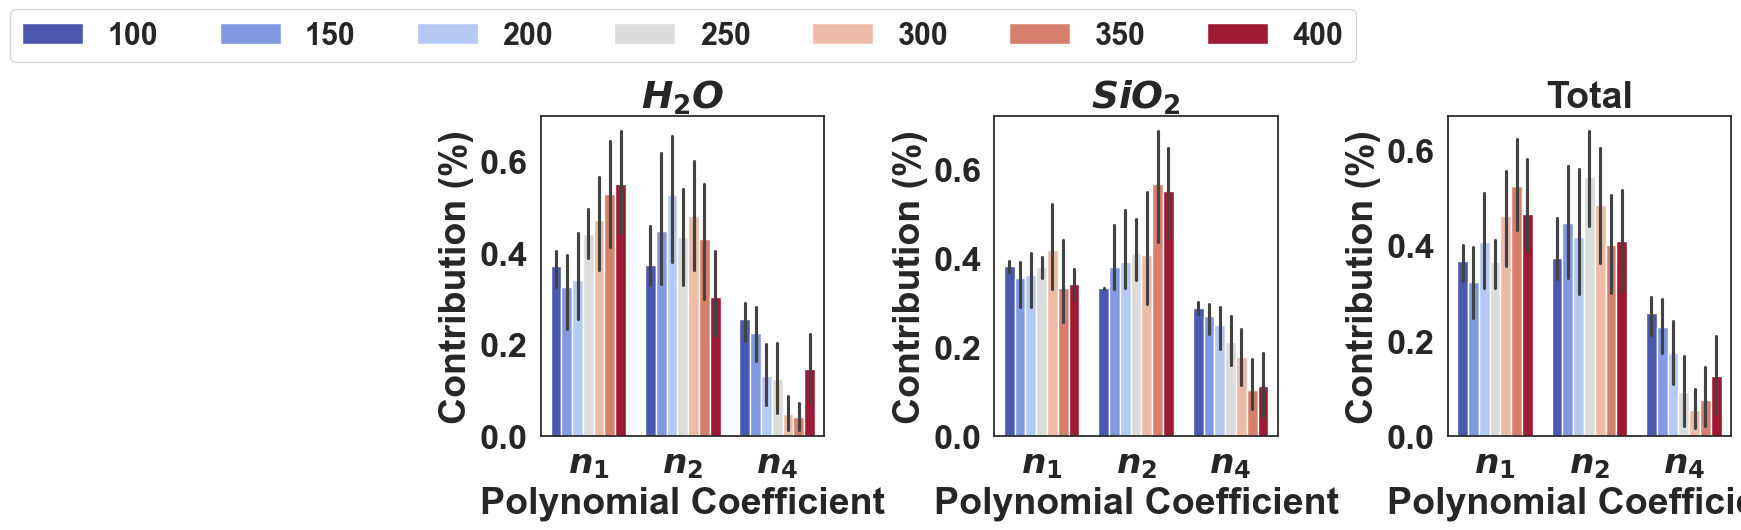

In [9]:
fig, axs = plt.subplots(ncols=3,figsize=(7*2,4))

for i, subset in enumerate(df_taylor_fit["Subset"].unique()):
    ax=axs[i]
    sns.barplot(data=df_taylor_fit.query("Subset == '%s'"%subset)
                , y='value'
                     , x='variable'
                     ,hue='Temperature (K)'
                ,palette="coolwarm"
                ,ax=ax
                ,legend=i==0
                    )
    
    if i==0:
        sns.move_legend(ax,'center',bbox_to_anchor=(0.5,legend_y),ncol=7,fontsize=22,title_fontsize=22,title="",)
    ax.set_xlabel("Polynomial Coefficient")
    ax.set_ylabel("Contribution (%)")
    ax.set_title(subset)
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.95, 
                    top=0.9, 
                    wspace=0.6, 
                    hspace=0.
                   )


In [10]:
def format_table(x):
    coeff,mettric=x.name
    result=x.copy()
    if coeff in ["a(T)","c(T)"]:
        result*=1e4
    if mettric == "mean":        
        result=result.map(lambda x : "%.1f"%x)
    else:
        result=result.map(lambda x : "%.2f"%x)
    return result

df_summary=df_power.groupby(["Temperature (K)","Subset"])[["a(T)","b(T)","c(T)"]].aggregate(["mean","std"])
df_summary_formatted=df_summary.apply(format_table).rename(columns={"mean":"$\mu$","std":"$\sigma$"})
print(df_summary_formatted.to_latex())

\begin{tabular}{llllllll}
\toprule
 &  & \multicolumn{2}{r}{a(T)} & \multicolumn{2}{r}{b(T)} & \multicolumn{2}{r}{c(T)} \\
 &  & $\mu$ & $\sigma$ & $\mu$ & $\sigma$ & $\mu$ & $\sigma$ \\
Temperature (K) & Subset &  &  &  &  &  &  \\
\midrule
\multirow[t]{3}{*}{100} & $H_2O$ & 1.5 & 0.01 & 2.1 & 0.05 & 0.7 & 0.01 \\
 & $SiO_2$ & 1.0 & 0.01 & 2.3 & 0.10 & 0.4 & 0.01 \\
 & Total & 1.4 & 0.01 & 2.1 & 0.05 & 0.7 & 0.01 \\
\cline{1-8}
\multirow[t]{3}{*}{150} & $H_2O$ & 2.0 & 0.01 & 2.1 & 0.04 & 1.3 & 0.01 \\
 & $SiO_2$ & 1.3 & 0.01 & 2.2 & 0.08 & 0.6 & 0.01 \\
 & Total & 1.9 & 0.01 & 2.1 & 0.05 & 1.2 & 0.01 \\
\cline{1-8}
\multirow[t]{3}{*}{200} & $H_2O$ & 4.2 & 0.01 & 1.9 & 0.02 & 5.0 & 0.01 \\
 & $SiO_2$ & 1.8 & 0.00 & 2.1 & 0.03 & 1.1 & 0.01 \\
 & Total & 3.8 & 0.00 & 1.9 & 0.01 & 4.5 & 0.01 \\
\cline{1-8}
\multirow[t]{3}{*}{250} & $H_2O$ & 7.0 & 0.03 & 1.7 & 0.06 & 15.9 & 0.06 \\
 & $SiO_2$ & 2.6 & 0.00 & 2.0 & 0.01 & 2.3 & 0.00 \\
 & Total & 6.4 & 0.02 & 1.8 & 0.06 & 14.0 & 0.05 \\
\cli

In [11]:
import ipywidgets as widgets

def power(x,a,b,c):
    return a*x**b+c


def fit_dos(df_mdanse,df_gmx,dos,emax,temperature,subset):
    if dos == "mdanse":
        df_tmp2=df_mdanse.query("0.1 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(emax*2,temperature,subset))
        df_tmp=df_mdanse.query("0.1 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(emax,temperature,subset))
    else:
        df_tmp2=df_gmx.query("0.1 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(emax*2,temperature,subset))
        df_tmp=df_gmx.query("0.1 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(emax,temperature,subset))
        
       
    xdata_ex=df_tmp2["Energy Transfer (meV)"].values
    ydata_ex=df_tmp2["Normalized Count"].values
    xdata=df_tmp["Energy Transfer (meV)"].values
    ydata=df_tmp["Normalized Count"].values
    popt, pcov = curve_fit(power, xdata, ydata,p0=[1,3,0],method='lm')
    cond_number=np.linalg.cond(pcov)
    cov_diag=np.diag(pcov)
    data_list.append({
            "Temperature (K)":temperature
            , "a(T)":popt[0]
            , "b(T)":popt[1]
            , "c(T)":popt[2] 
            ,"emax":emax
                         })
    
    fig, ax = plt.subplots(figsize=(8,5))
    df_fit=pd.concat([
        pd.DataFrame({"Energy Transfer (meV)":xdata_ex,"dos":ydata_ex,"data":"Simulation"})
        ,pd.DataFrame({"Energy Transfer (meV)":xdata,"dos":ydata,"data":"Fitted"})
        ,pd.DataFrame({"Energy Transfer (meV)":xdata,"dos": power(xdata, *popt),"data":"Fit:$ax^b+c$"})

    ],ignore_index=True)
    ax=sns.lineplot(data=df_fit
        , y='dos'
             , x='Energy Transfer (meV)'
            ,hue='data'
             ,palette='Set1'
             ,lw=3
            ,ax=ax
            )
#    ax.loglog()
    ax.set_title("Temperature: %d K. Power:%.1f Subset:%s emax=%.1f"%(temperature,popt[1],subset,emax),pad=25)
    sns.move_legend(ax,'center',bbox_to_anchor=(0.5,1.4),ncol=4,fontsize=22,title_fontsize=22,title="")

    parameters_str="\n".join(["%s=%.2e ± %.2e"%("abc"[i],x,dx) for i, (x,dx) in enumerate(zip(popt,cov_diag))])
    ax.text(1, 0.5,parameters_str,ha="left",va="center",weight='bold' ,transform=ax.transAxes)
 

d=widgets.interact(fit_dos
                 ,df_mdanse=widgets.fixed(df_dos_mdanse)
                 ,df_gmx=widgets.fixed(df_dos_gmx)
                 ,dos=["gmx","mdanse"]
                 ,emax=widgets.FloatSlider(min=1,max=3,value=1.5)
                 ,temperature=df_dos_mdanse["Temperature (K)"].unique()
                 ,subset=df_dos_mdanse["Subset"].unique()
                 )

interactive(children=(Dropdown(description='dos', options=('gmx', 'mdanse'), value='gmx'), FloatSlider(value=1…

In [12]:
def taylor_series(x,a0,a1,a2,a3,a4):
    return a0+a1*x+a2*x**2+a3*x**3+a4*x**4

def fit_dos(df_mdanse,df_gmx,dos,emax,temperature,subset):
    if dos == "mdanse":
        df_tmp2=df_mdanse.query("0.1 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(emax*2,temperature,subset))
        df_tmp=df_mdanse.query("0.1 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(emax,temperature,subset))
    else:
        df_tmp2=df_gmx.query("0.1 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(emax*2,temperature,subset))
        df_tmp=df_gmx.query("0.1 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(emax,temperature,subset))
        
       
    xdata_ex=df_tmp2["Energy Transfer (meV)"].values
    ydata_ex=df_tmp2["Normalized Count"].values
    xdata=df_tmp["Energy Transfer (meV)"].values
    ydata=df_tmp["Normalized Count"].values
    popt, pcov = curve_fit(taylor_series, xdata, ydata,p0=[1,1,1,1,1],bounds=([-np.inf,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf]),method='trf')
    cond_number=np.linalg.cond(pcov)
    cov_diag=np.diag(pcov)
    data_list.append({
            "Temperature (K)":temperature
            , "a1(T)":popt[0]
            , "a2(T)":popt[1]
            , "b(T)":popt[2]
            , "c(T)":popt[3] 
            ,"emax":emax
                         })
    
    fig, ax = plt.subplots(figsize=(8,5))
    df_fit=pd.concat([
        pd.DataFrame({"Energy Transfer (meV)":xdata_ex,"dos":ydata_ex,"data":"Simulation"})
        ,pd.DataFrame({"Energy Transfer (meV)":xdata,"dos":ydata,"data":"Fitted"})
        ,pd.DataFrame({"Energy Transfer (meV)":xdata,"dos": taylor_series(xdata, *popt),"data":"Fit: $a0+a_1x+a_2x^2+a_3x^3+a_4x^4$"})

    ],ignore_index=True)
    ax=sns.lineplot(data=df_fit
        , y='dos'
             , x='Energy Transfer (meV)'
            ,hue='data'
             ,palette='Set1'
             ,lw=3
            ,ax=ax
            )
#    ax.loglog()
    ds_tmp=pd.Series({i+1:abs(x) for i,x in enumerate(popt[1:])})
    ax.set_title("Temperature: %d K. Power:%d Subset:%s emax=%.1f"%(temperature,ds_tmp.idxmax(),subset,emax),pad=25)

    parameters_str="\n".join(["$a_%d$=%.2e (%.1f %%)"%(i,x,dx) for i, (x,dx) in enumerate(zip(popt,100*np.abs(popt)/np.sum(np.abs(popt))))])
    ax.text(1, 0.5,parameters_str,ha="left",va="center",weight='bold' ,transform=ax.transAxes)
    
    sns.move_legend(ax,'center',bbox_to_anchor=(0.5,1.3),ncol=4,fontsize=22,title_fontsize=22,title="")



d=widgets.interact(fit_dos
                 ,df_mdanse=widgets.fixed(df_dos_mdanse)
                 ,df_gmx=widgets.fixed(df_dos_gmx)
                 ,dos=["gmx","mdanse"]
                 ,emax=widgets.FloatSlider(min=0.5,max=5,value=2.5)
                 ,temperature=df_dos_mdanse["Temperature (K)"].unique()
                 ,subset=df_dos_mdanse["Subset"].unique()
                 )

interactive(children=(Dropdown(description='dos', options=('gmx', 'mdanse'), value='gmx'), FloatSlider(value=2…

In [13]:
df_power.query("`Temperature (K)`==100 and Subset == '$H_2O$'")

,Temperature (K),a(T),b(T),c(T),emax,$a_0$,$a_1$,$a_2$,$a_4$,$n_1$,$n_2$,$n_4$,$\Delta a_0$,$\Delta a_1$,$\Delta a_2$,$\Delta a_4$,Subset
0,100,0.000147,2.054655,0.000074,1.0,0.000059,0.000063,0.000059,0.000055,0.356514,0.334530,0.308956,3.473644e-11,1.722343e-09,4.565176e-09,1.283153e-09,$H_2O$
1,100,0.000147,2.067153,0.000074,1.1,0.000058,0.000065,0.000058,0.000053,0.367611,0.332574,0.299814,4.643199e-11,1.978135e-09,4.499086e-09,9.274407e-10,$H_2O$
2,100,0.000147,2.089535,0.000074,1.2,0.000054,0.000068,0.000058,0.000050,0.387620,0.328992,0.283388,8.338464e-11,2.885365e-09,5.321528e-09,7.177624e-10,$H_2O$
3,100,0.000147,2.106999,0.000074,1.3,0.000065,0.000062,0.000051,0.000041,0.403266,0.331112,0.265623,9.158354e-12,2.789620e-10,4.524801e-10,4.707275e-11,$H_2O$
4,100,0.000147,2.126510,0.000075,1.4,0.000065,0.000062,0.000050,0.000039,0.411680,0.330302,0.258018,1.321895e-11,3.571564e-10,5.134542e-10,4.185809e-11,$H_2O$
5,100,0.000146,2.159413,0.000075,1.5,0.000066,0.000062,0.000048,0.000037,0.421457,0.329173,0.249370,2.276320e-11,5.202571e-10,6.320330e-10,3.667629e-11,$H_2O$
6,100,0.000145,2.183486,0.000076,1.6,0.000068,0.000038,0.000095,0.000018,0.252278,0.625758,0.121964,2.036652e-12,4.193946e-11,4.587851e-11,2.154649e-12,$H_2O$
